In [ ]:
"""
Part 1.3 Data Analysis
Two models: Random Forest (benchmark, reused from earlier project) and
Naive Bayes (new model, satisfies the "different from previous coursework" rule)

Run this in Google Colab or Jupyter. Upload creditcard.csv and aapl.us.txt first.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE



In [1]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# DATASET 1: Credit Card Fraud Detection
print("DATASET 1: Credit Card Fraud Detection")

# Load the dataset from CSV file
print("\nLoading creditcard.csv...")
start = time.time()
df1 = pd.read_csv('creditcard.csv')
print(f"Shape: {df1.shape}")
print(f"Fraud cases: {df1['Class'].sum()} ({df1['Class'].mean()*100:.3f}%)")
print(f"Done in {time.time() - start:.2f} seconds")

# Split into features (X) and target label (y)
# Class column is what we are trying to predict, 1 means fraud, 0 means normal
print("\nPreparing features and target...")
start = time.time()
X1 = df1.drop('Class', axis=1)
y1 = df1['Class']
print(f"Done in {time.time() - start:.2f} seconds")

# Scale Time and Amount so they are on a similar range to the other features
# The V1 to V28 columns are already scaled from PCA, so only these two need it
print("\nScaling Time and Amount...")
start = time.time()
scaler1 = StandardScaler()
X1[['Time', 'Amount']] = scaler1.fit_transform(X1[['Time', 'Amount']])
print(f"Done in {time.time() - start:.2f} seconds")

# Split into training and testing sets
# stratify keeps the same fraud percentage in both train and test sets
print("\nSplitting into train and test sets...")
start = time.time()
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)
print(f"Training rows: {X1_train.shape[0]}, Testing rows: {X1_test.shape[0]}")
print(f"Done in {time.time() - start:.2f} seconds")

# Apply SMOTE to fix class imbalance in the training data only
# This creates synthetic fraud examples so the model has enough fraud cases to learn from
# This step is usually the slowest one, since it works with all 28+ columns
print("\nApplying SMOTE, this can take a while on the full dataset...")
start = time.time()
sm = SMOTE(random_state=42)
X1_train_sm, y1_train_sm = sm.fit_resample(X1_train, y1_train)
print(f"Before SMOTE: {X1_train.shape}, After SMOTE: {X1_train_sm.shape}")
print(f"Done in {time.time() - start:.2f} seconds")

# Train Random Forest model (benchmark, same model type used in earlier project)
print("\nTraining Random Forest...")
start = time.time()
rf1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf1.fit(X1_train_sm, y1_train_sm)
print(f"Done in {time.time() - start:.2f} seconds")

# Predict on the test set
rf1_pred = rf1.predict(X1_test)
rf1_proba = rf1.predict_proba(X1_test)[:, 1]  # probability scores, needed for ROC-AUC

print("\nRandom Forest on Dataset 1")
print(f"Precision: {precision_score(y1_test, rf1_pred):.4f}")
print(f"Recall:    {recall_score(y1_test, rf1_pred):.4f}")
print(f"F1-score:  {f1_score(y1_test, rf1_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y1_test, rf1_proba):.4f}")
print(confusion_matrix(y1_test, rf1_pred))

# Train Naive Bayes model (new model, different from what was used before)
print("\nTraining Naive Bayes...")
start = time.time()
nb1 = GaussianNB()
nb1.fit(X1_train_sm, y1_train_sm)
print(f"Done in {time.time() - start:.2f} seconds")

# Predict on the test set
nb1_pred = nb1.predict(X1_test)
nb1_proba = nb1.predict_proba(X1_test)[:, 1]

print("\nNaive Bayes on Dataset 1")
print(f"Precision: {precision_score(y1_test, nb1_pred):.4f}")
print(f"Recall:    {recall_score(y1_test, nb1_pred):.4f}")
print(f"F1-score:  {f1_score(y1_test, nb1_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y1_test, nb1_proba):.4f}")
print(confusion_matrix(y1_test, nb1_pred))

print("\nDataset 1 analysis completed")

DATASET 1: Credit Card Fraud Detection

Loading creditcard.csv...
Shape: (284807, 31)
Fraud cases: 492 (0.173%)
Done in 1.92 seconds

Preparing features and target...
Done in 0.02 seconds

Scaling Time and Amount...
Done in 0.02 seconds

Splitting into train and test sets...
Training rows: 227845, Testing rows: 56962
Done in 0.21 seconds

Applying SMOTE, this can take a while on the full dataset...
Before SMOTE: (227845, 30), After SMOTE: (454902, 30)
Done in 2.37 seconds

Training Random Forest...
Done in 90.52 seconds

Random Forest on Dataset 1
Precision: 0.8454
Recall:    0.8367
F1-score:  0.8410
ROC-AUC:   0.9731
[[56849    15]
 [   16    82]]

Training Naive Bayes...
Done in 0.64 seconds

Naive Bayes on Dataset 1
Precision: 0.0550
Recall:    0.8776
F1-score:  0.1035
ROC-AUC:   0.9644
[[55386  1478]
 [   12    86]]

Dataset 1 analysis completed


In [2]:
# DATASET 2: Stock Price and Volume (AAPL)
# Prediction task: predict whether tomorrow's closing price goes UP or DOWN
# There is no fraud/anomaly label in this dataset, so we build our own target

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("DATASET 2: AAPL Stock Price and Volume")

# Load the dataset and sort by date
# Stock data must be in date order for this to make sense
print("\nLoading aapl.us.txt...")
start = time.time()
df2 = pd.read_csv("aapl.us.txt")
df2["Date"] = pd.to_datetime(df2["Date"])
df2 = df2.sort_values("Date").reset_index(drop=True)
print(f"Shape: {df2.shape}, Date range: {df2['Date'].min()} to {df2['Date'].max()}")
print(f"Done in {time.time() - start:.2f} seconds")

# Feature engineering
# We create extra columns from the raw price and volume data
# so the model has more useful patterns to learn from
print("\nCreating features...")
start = time.time()

df2["DailyChangePct"] = (df2["Close"] - df2["Open"]) / df2["Open"] * 100
df2["HighLowSpread"] = (df2["High"] - df2["Low"]) / df2["Low"] * 100
df2["VolumeChangePct"] = df2["Volume"].pct_change() * 100
df2["PrevClose"] = df2["Close"].shift(1)
df2["PrevVolume"] = df2["Volume"].shift(1)

# Target: 1 if tomorrow's close is higher than today's close, else 0
df2["NextClose"] = df2["Close"].shift(-1)
df2["Target"] = (df2["NextClose"] > df2["Close"]).astype(int)

# Clean up rows with missing or infinite values
# These happen at the start (no previous day) and end (no next day) of the data
df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {df2.shape}")
print(f"Up days: {df2['Target'].sum()} ({df2['Target'].mean()*100:.1f}%)")
print(f"Down days: {(df2['Target']==0).sum()} ({(df2['Target']==0).mean()*100:.1f}%)")
print(f"Done in {time.time() - start:.2f} seconds")

# Select the columns we will actually use as model inputs
print("\nSelecting features and target...")
start = time.time()
features2 = ["Open", "High", "Low", "Close", "Volume",
             "DailyChangePct", "HighLowSpread", "VolumeChangePct",
             "PrevClose", "PrevVolume"]
X2 = df2[features2]
y2 = df2["Target"]
print(f"X shape: {X2.shape}, y shape: {y2.shape}")
print(f"Done in {time.time() - start:.2f} seconds")

# Train/test split done by date, not randomly
# Stock data is a time series, so we train on earlier dates
# and test on later dates to avoid the model seeing the future
print("\nSplitting into train and test sets by date...")
start = time.time()
split_idx = int(len(X2) * 0.8)
X2_train = X2.iloc[:split_idx].copy()
X2_test = X2.iloc[split_idx:].copy()
y2_train = y2.iloc[:split_idx].copy()
y2_test = y2.iloc[split_idx:].copy()
print(f"Training rows: {len(X2_train)}, Testing rows: {len(X2_test)}")
print(f"Training period: {df2['Date'].iloc[:split_idx].min()} to {df2['Date'].iloc[split_idx-1]}")
print(f"Testing period: {df2['Date'].iloc[split_idx]} to {df2['Date'].iloc[-1]}")
print(f"Done in {time.time() - start:.2f} seconds")

# Scale features
# Scaler is fit only on training data so no information from the test period leaks in
print("\nScaling features...")
start = time.time()
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)
print(f"Done in {time.time() - start:.2f} seconds")

# Train Random Forest (benchmark model)
print("\nTraining Random Forest...")
start = time.time()
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X2_train_scaled, y2_train)
rf2_pred = rf2.predict(X2_test_scaled)
rf2_proba = rf2.predict_proba(X2_test_scaled)[:, 1]

rf2_precision = precision_score(y2_test, rf2_pred, zero_division=0)
rf2_recall = recall_score(y2_test, rf2_pred, zero_division=0)
rf2_f1 = f1_score(y2_test, rf2_pred, zero_division=0)
rf2_auc = roc_auc_score(y2_test, rf2_proba)

print("\nRandom Forest on Dataset 2")
print(f"Precision: {rf2_precision:.4f}")
print(f"Recall:    {rf2_recall:.4f}")
print(f"F1-score:  {rf2_f1:.4f}")
print(f"ROC-AUC:   {rf2_auc:.4f}")
print(confusion_matrix(y2_test, rf2_pred))
print(f"Done in {time.time() - start:.2f} seconds")

# Train Naive Bayes (new model)
print("\nTraining Naive Bayes...")
start = time.time()
nb2 = GaussianNB()
nb2.fit(X2_train_scaled, y2_train)
nb2_pred = nb2.predict(X2_test_scaled)
nb2_proba = nb2.predict_proba(X2_test_scaled)[:, 1]

nb2_precision = precision_score(y2_test, nb2_pred, zero_division=0)
nb2_recall = recall_score(y2_test, nb2_pred, zero_division=0)
nb2_f1 = f1_score(y2_test, nb2_pred, zero_division=0)
nb2_auc = roc_auc_score(y2_test, nb2_proba)

print("\nNaive Bayes on Dataset 2")
print(f"Precision: {nb2_precision:.4f}")
print(f"Recall:    {nb2_recall:.4f}")
print(f"F1-score:  {nb2_f1:.4f}")
print(f"ROC-AUC:   {nb2_auc:.4f}")
print(confusion_matrix(y2_test, nb2_pred))
print(f"Done in {time.time() - start:.2f} seconds")

# Feature importance from Random Forest
# Shows which features mattered most for predicting price direction
print("\nCalculating feature importance...")
importances = pd.Series(rf2.feature_importances_, index=features2).sort_values(ascending=False)
print(importances)

print("\nDataset 2 analysis completed")

DATASET 2: AAPL Stock Price and Volume

Loading aapl.us.txt...
Shape: (8364, 7), Date range: 1984-09-07 00:00:00 to 2017-11-10 00:00:00
Done in 0.07 seconds

Creating features...
Shape after feature engineering: (8361, 14)
Up days: 4141 (49.5%)
Down days: 4220 (50.5%)
Done in 0.02 seconds

Selecting features and target...
X shape: (8361, 10), y shape: (8361,)
Done in 0.01 seconds

Splitting into train and test sets by date...
Training rows: 6688, Testing rows: 1673
Training period: 1984-09-10 00:00:00 to 2011-03-21 00:00:00
Testing period: 2011-03-22 00:00:00 to 2017-11-09 00:00:00
Done in 0.00 seconds

Scaling features...
Done in 0.01 seconds

Training Random Forest...

Random Forest on Dataset 2
Precision: 0.5259
Recall:    0.2106
F1-score:  0.3007
ROC-AUC:   0.4861
[[639 165]
 [686 183]]
Done in 0.74 seconds

Training Naive Bayes...

Naive Bayes on Dataset 2
Precision: 0.5194
Recall:    1.0000
F1-score:  0.6837
ROC-AUC:   0.4952
[[  0 804]
 [  0 869]]
Done in 0.01 seconds

Calculati

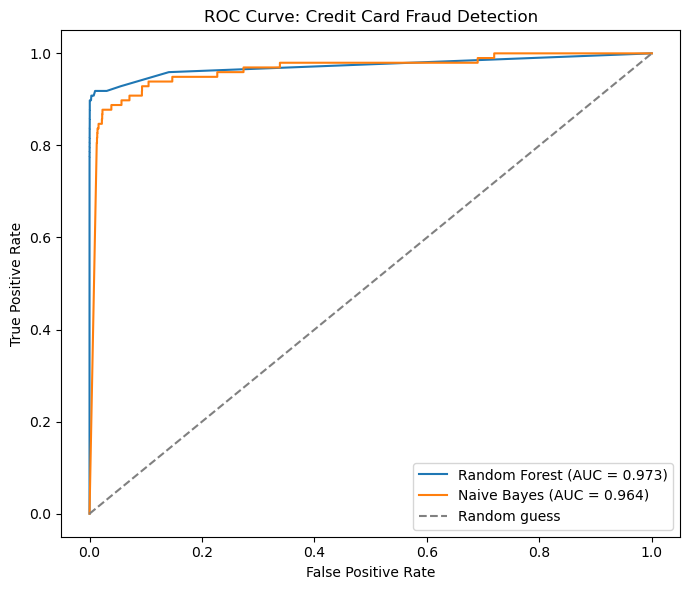

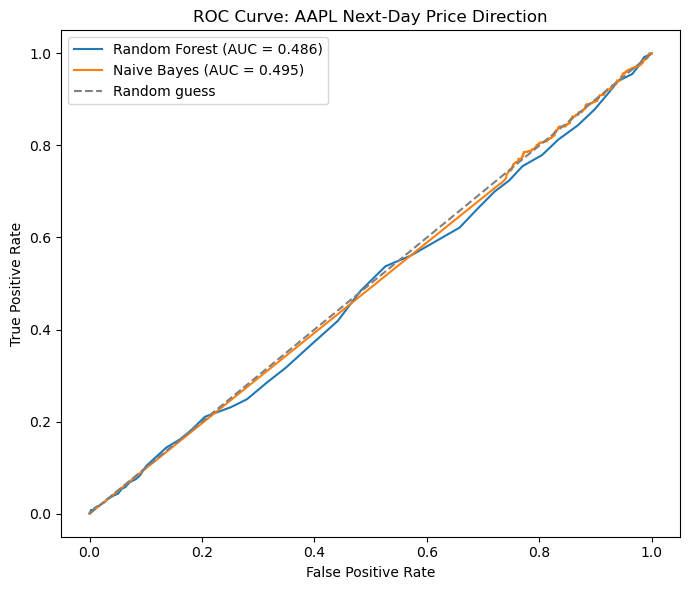

In [4]:
# ===========================================================
# ROC CURVES
# ===========================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve for Dataset 1: Credit Card Fraud
fpr_rf1, tpr_rf1, _ = roc_curve(y1_test, rf1_proba)
fpr_nb1, tpr_nb1, _ = roc_curve(y1_test, nb1_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf1, tpr_rf1, label=f"Random Forest (AUC = {roc_auc_score(y1_test, rf1_proba):.3f})")
plt.plot(fpr_nb1, tpr_nb1, label=f"Naive Bayes (AUC = {roc_auc_score(y1_test, nb1_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Credit Card Fraud Detection")
plt.legend()
plt.tight_layout()
plt.savefig("roc_dataset1_creditcard.png", dpi=200)
plt.show()

# ROC curve for Dataset 2: AAPL Stock Direction
fpr_rf2, tpr_rf2, _ = roc_curve(y2_test, rf2_proba)
fpr_nb2, tpr_nb2, _ = roc_curve(y2_test, nb2_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf2, tpr_rf2, label=f"Random Forest (AUC = {roc_auc_score(y2_test, rf2_proba):.3f})")
plt.plot(fpr_nb2, tpr_nb2, label=f"Naive Bayes (AUC = {roc_auc_score(y2_test, nb2_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: AAPL Next-Day Price Direction")
plt.legend()
plt.tight_layout()
plt.savefig("roc_dataset2_aapl.png", dpi=200)
plt.show()